In [1]:
# CELL 1 — Imports
import joblib
import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt

shap.initjs()

d:\'xai-healthcare-fyp'\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# CELL 2 — Load model and processed data
model = joblib.load('../model/random_forest_model.pkl')   # changed from xgboost
X_train = joblib.load('../data/processed/X_train_scaled.pkl')
X_test = joblib.load('../data/processed/X_test_scaled.pkl')
y_test = joblib.load('../data/processed/y_test.pkl')
feature_names = joblib.load('../data/processed/feature_names.pkl')

# Convert back to DataFrame for readable feature names in plots
X_test_df = pd.DataFrame(X_test, columns=feature_names)

print("Loaded successfully. Test set shape:", X_test_df.shape)

Loaded successfully. Test set shape: (61, 13)


In [3]:
explainer = shap.TreeExplainer(model)
shap_values_raw = explainer.shap_values(X_test_df)

if isinstance(shap_values_raw, list):
    shap_values = shap_values_raw[1]
    expected_value = explainer.expected_value[1]
elif shap_values_raw.ndim == 3:
    shap_values = shap_values_raw[:, :, 1]
    expected_value = explainer.expected_value[1]
else:
    shap_values = shap_values_raw
    expected_value = explainer.expected_value

print("SHAP values computed. Shape:", shap_values.shape)

SHAP values computed. Shape: (61, 13)


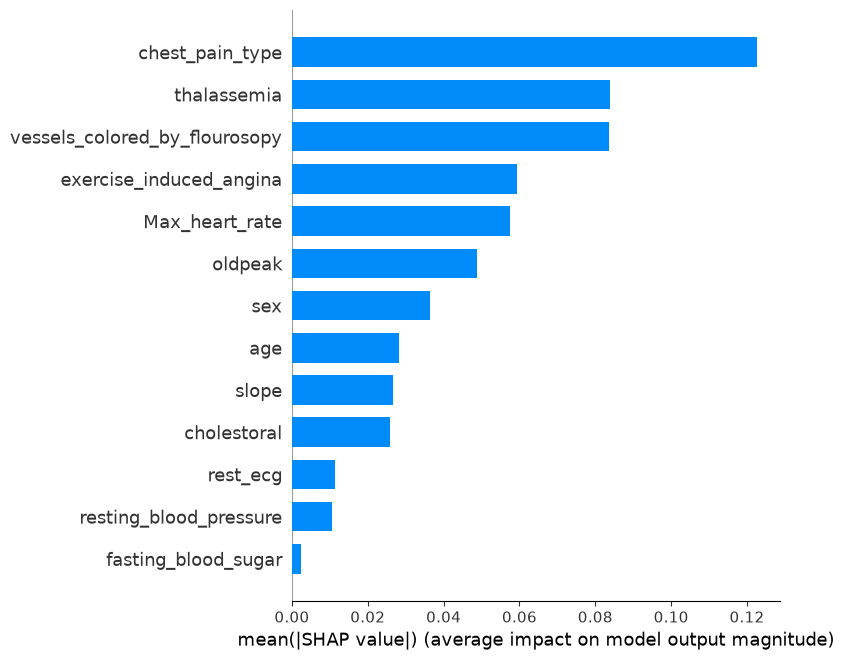

In [4]:
# CELL 4 — Global explanation: Summary plot (which features matter most overall)
shap.summary_plot(shap_values, X_test_df, plot_type="bar")

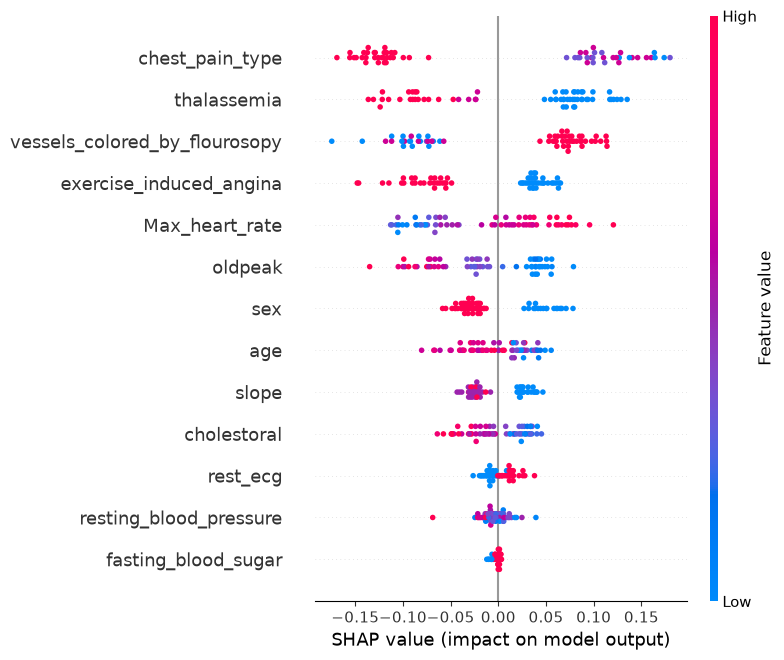

In [5]:
# CELL 5 — Global explanation: Detailed summary plot (shows direction of impact too)
shap.summary_plot(shap_values, X_test_df)

Actual label: 0
Predicted probability of disease: 0.065


d:\'xai-healthcare-fyp'\venv\Lib\site-packages\sklearn\utils\validation.py:2823: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


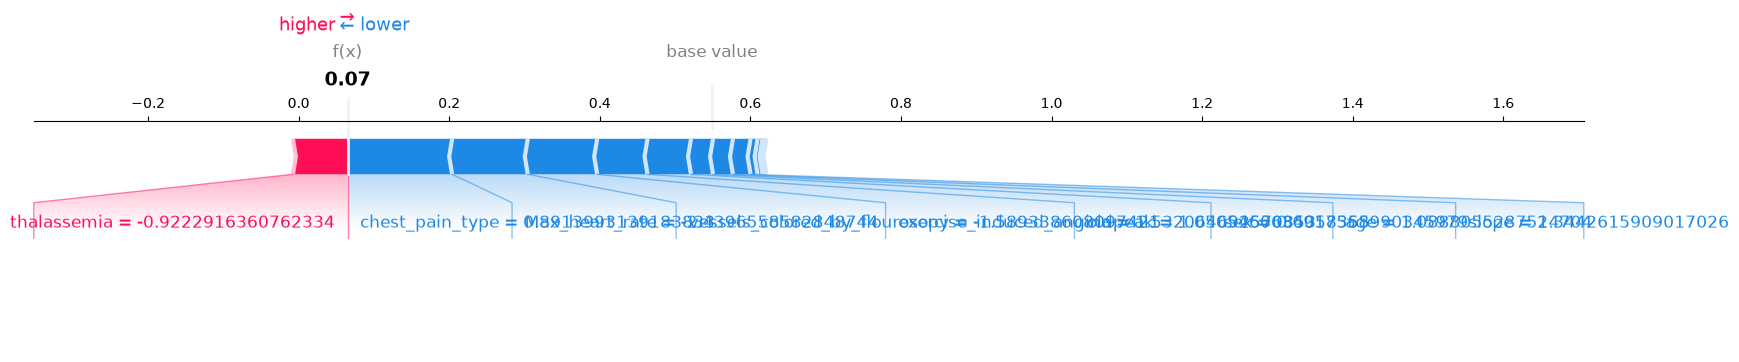

In [6]:
# CELL 6 — Local explanation: Explain ONE specific patient's prediction (e.g., patient #5)
patient_index = 5

print("Actual label:", y_test.iloc[patient_index])
print("Predicted probability of disease:", model.predict_proba(X_test_df.iloc[[patient_index]])[0][1])

shap.force_plot(
    expected_value,
    shap_values[patient_index],
    X_test_df.iloc[patient_index],
    matplotlib=True
)

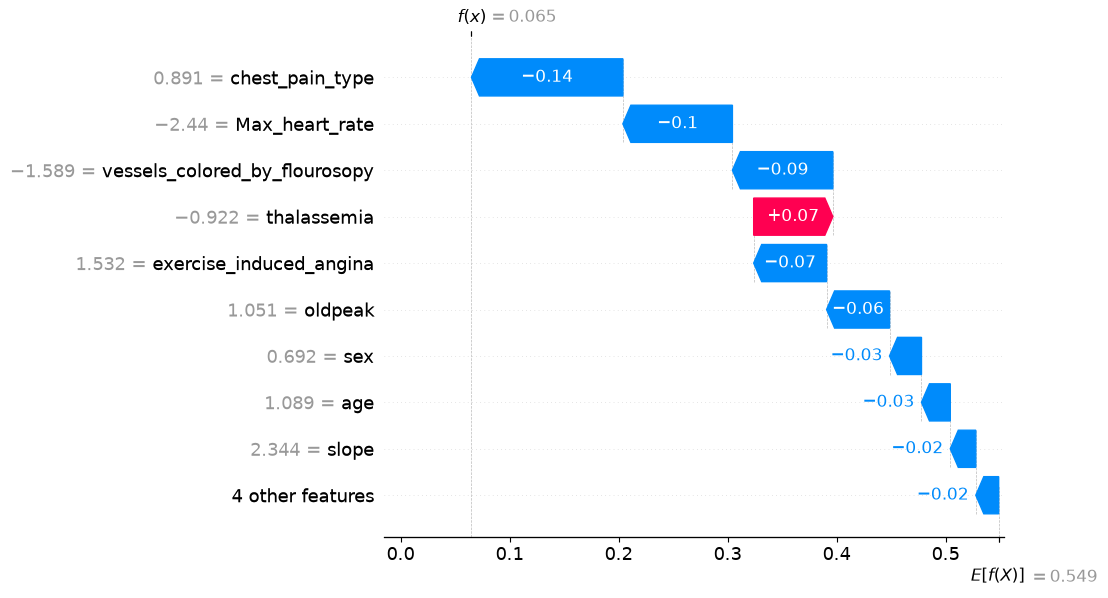

In [7]:
# CELL 7 — Waterfall plot (clearer view of one patient's explanation)
shap.plots.waterfall(shap.Explanation(
    values=shap_values[patient_index],
    base_values=expected_value,
    data=X_test_df.iloc[patient_index],
    feature_names=feature_names
))

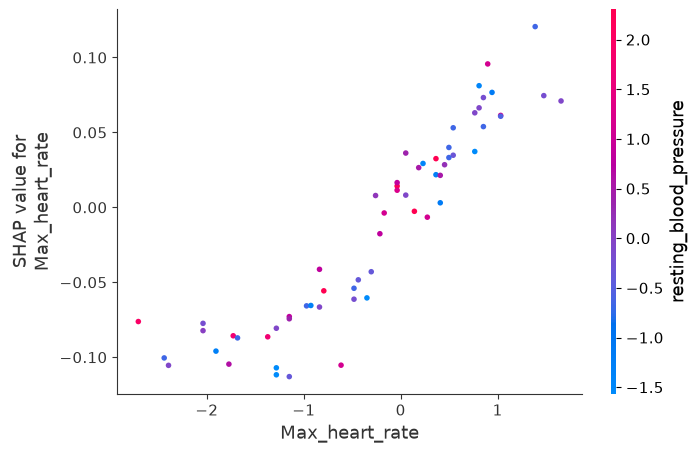

In [8]:
# CELL 8 — Dependence plot: how one feature affects prediction across its range
shap.dependence_plot("Max_heart_rate", shap_values, X_test_df)

In [9]:
# CELL 9 — LIME imports and setup
from lime.lime_tabular import LimeTabularExplainer

# Build LIME explainer using training data
lime_explainer = LimeTabularExplainer(
    training_data=np.array(X_train),
    feature_names=feature_names,
    class_names=['No Disease', 'Disease'],
    mode='classification'
)

In [10]:
# CELL 10 — Explain the SAME patient (#5) with LIME
lime_exp = lime_explainer.explain_instance(
    data_row=X_test_df.iloc[patient_index].values,
    predict_fn=model.predict_proba,
    num_features=10
)
# lime_exp.show_in_notebook(show_table=True)   <-- ye line hata do ya # laga do

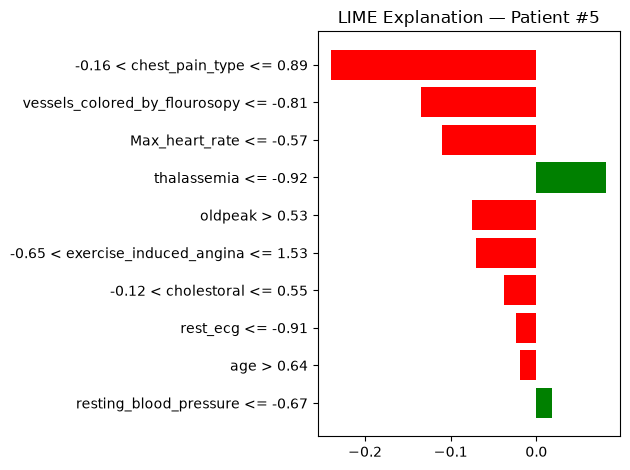

In [11]:
# CELL 11 — LIME explanation as a plot (easier to screenshot for your report)
fig = lime_exp.as_pyplot_figure()
plt.title(f"LIME Explanation — Patient #{patient_index}")
plt.tight_layout()
plt.show()

In [12]:
# CELL 12 — Print side-by-side comparison summary
print("=" * 60)
print(f"COMPARISON: SHAP vs LIME for Patient #{patient_index}")
print("=" * 60)
print(f"\nActual label: {y_test.iloc[patient_index]}")
print(f"Model prediction: {model.predict(X_test_df.iloc[[patient_index]])[0]}")
print(f"Predicted probability of disease: {model.predict_proba(X_test_df.iloc[[patient_index]])[0][1]:.3f}")

print("\n--- LIME Top Features ---")
for feature, weight in lime_exp.as_list():
    print(f"{feature}: {weight:.4f}")

print("\n--- SHAP Top Features (same patient) ---")
shap_contributions = pd.Series(shap_values[patient_index], index=feature_names).sort_values(key=abs, ascending=False)
print(shap_contributions.head(10))

COMPARISON: SHAP vs LIME for Patient #5

Actual label: 0
Model prediction: 0
Predicted probability of disease: 0.065

--- LIME Top Features ---
-0.16 < chest_pain_type <= 0.89: -0.2391
vessels_colored_by_flourosopy <= -0.81: -0.1343
Max_heart_rate <= -0.57: -0.1104
thalassemia <= -0.92: 0.0817
oldpeak > 0.53: -0.0753
-0.65 < exercise_induced_angina <= 1.53: -0.0705
-0.12 < cholestoral <= 0.55: -0.0381
rest_ecg <= -0.91: -0.0232
age > 0.64: -0.0196
resting_blood_pressure <= -0.67: 0.0182

--- SHAP Top Features (same patient) ---
chest_pain_type                 -0.138913
Max_heart_rate                  -0.100469
vessels_colored_by_flourosopy   -0.092121
thalassemia                      0.072608
exercise_induced_angina         -0.066885
oldpeak                         -0.057741
sex                             -0.029300
age                             -0.026434
slope                           -0.023401
rest_ecg                        -0.009332
dtype: float64


d:\'xai-healthcare-fyp'\venv\Lib\site-packages\sklearn\utils\validation.py:2823: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
d:\'xai-healthcare-fyp'\venv\Lib\site-packages\sklearn\utils\validation.py:2823: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
